## Holiday Package Prediciton


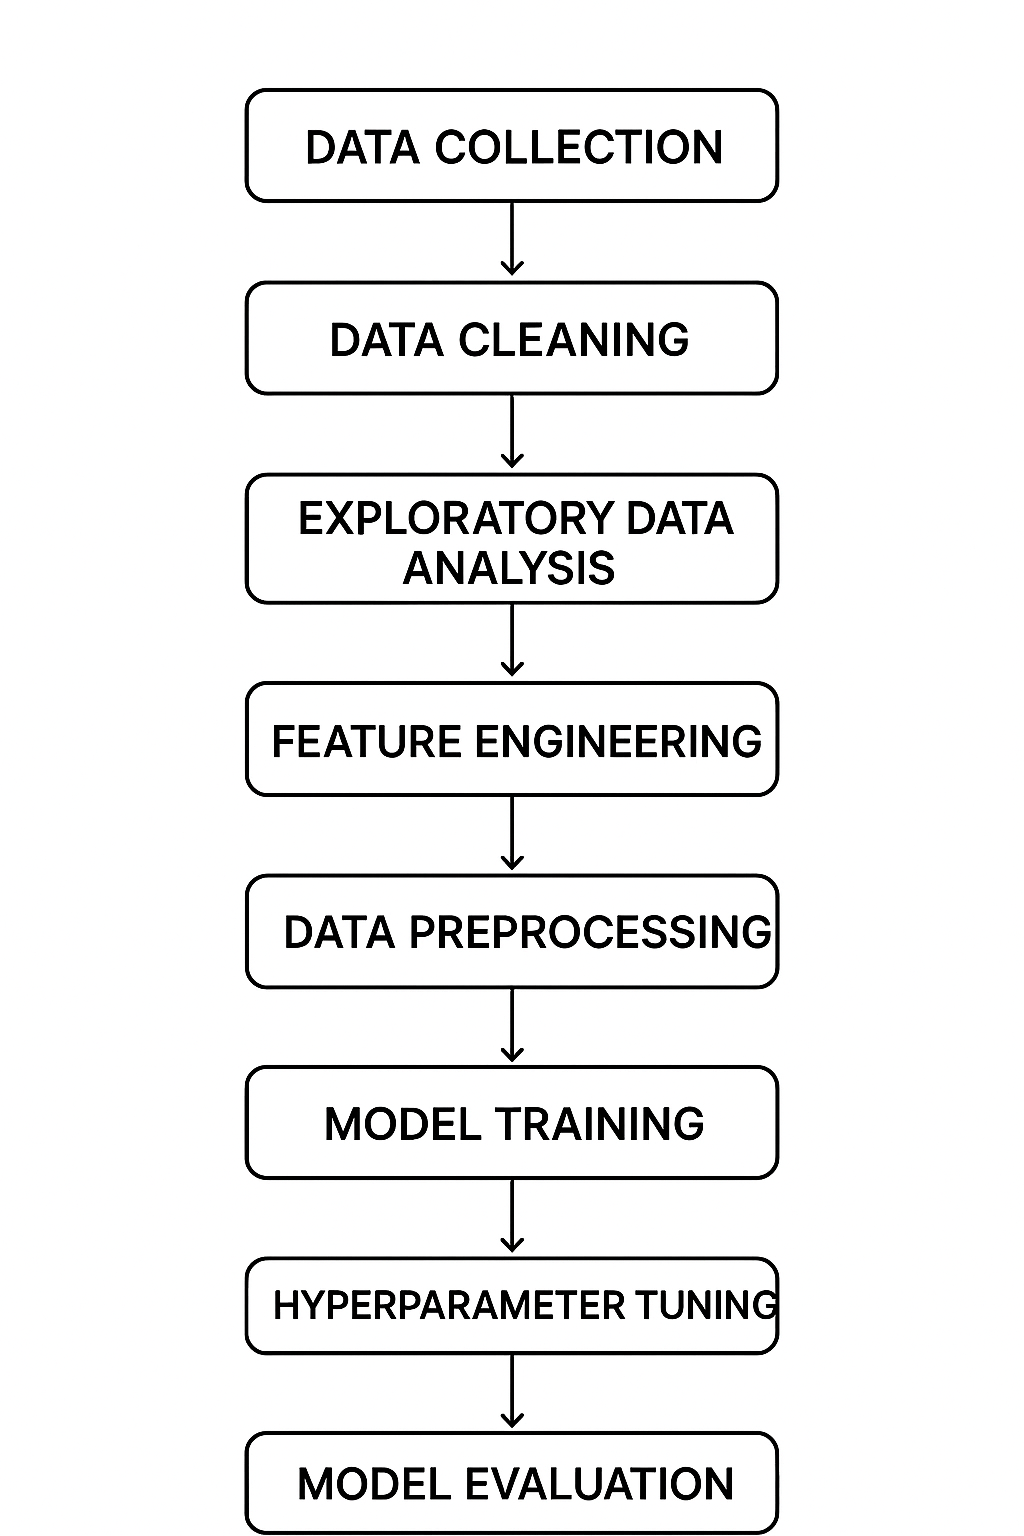

In [22]:
from IPython.display import Image

Image("hp.png")

In [2]:
# Import Libraries & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Travel.csv")
df.head()


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,NaN,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [21]:
# 2 Data Checks

In [4]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4661 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

CustomerID                    0
ProdTaken                     0
Age                         227
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [ ]:
# 3 Data Cleaning

In [5]:
# Fix inconsistent categories
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')

# Drop Customer ID
df.drop('CustomerID', axis=1, inplace=True)


In [6]:
# 4 Exploratory Data Analysis (EDA)

In [ ]:
# 4.1 Target Variable Distribution

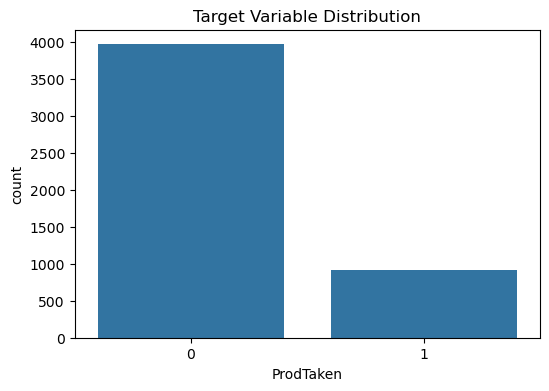

ProdTaken
0    81.178396
1    18.821604
Name: proportion, dtype: float64

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['ProdTaken'])
plt.title("Target Variable Distribution")
plt.show()

df['ProdTaken'].value_counts(normalize=True)*100


In [ ]:
# 4.2 Numerical Feature Distribution

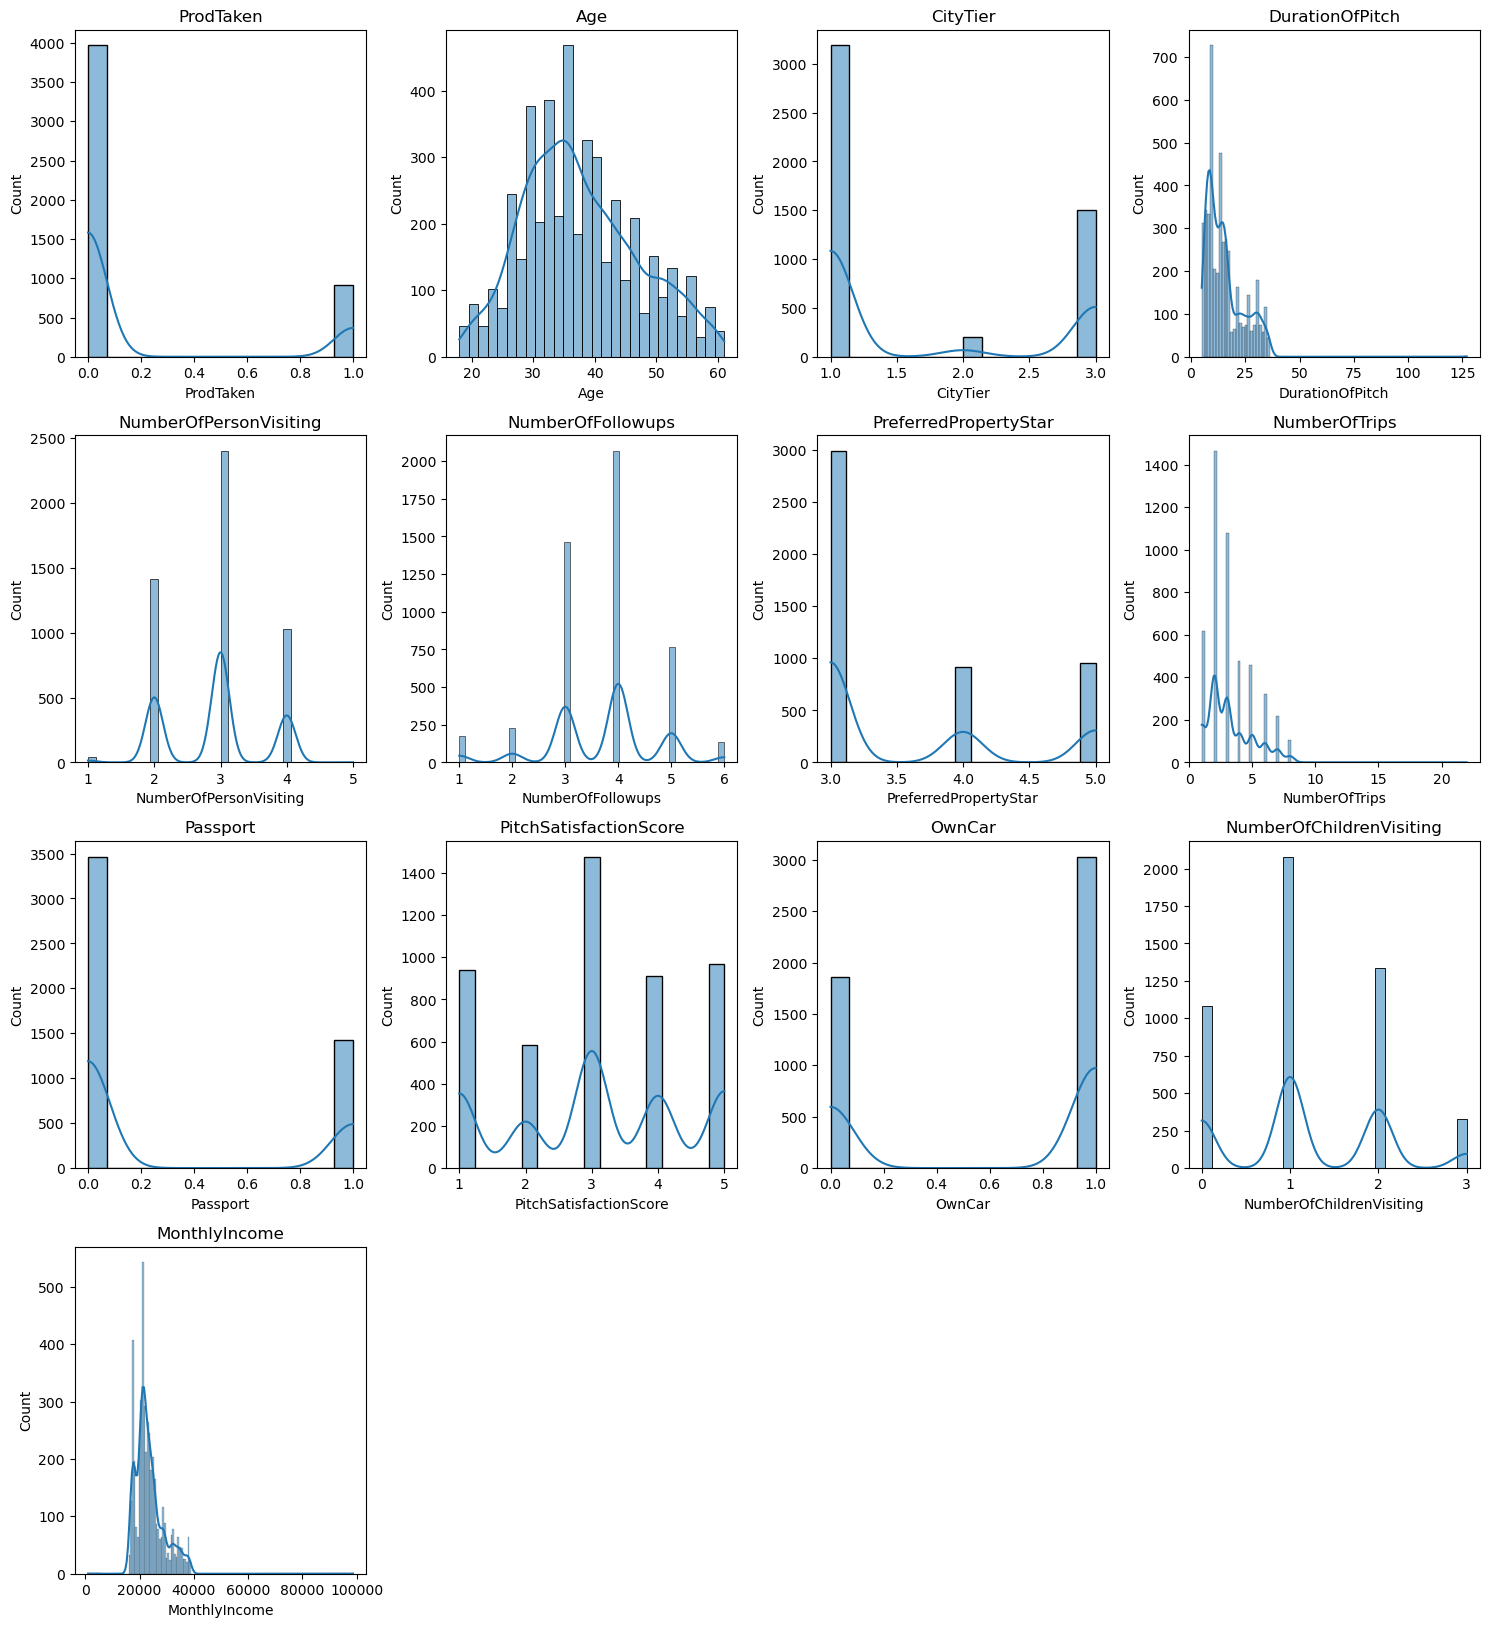

In [8]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 4, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


In [ ]:
# 4.3 Outlier Detection (Boxplots)

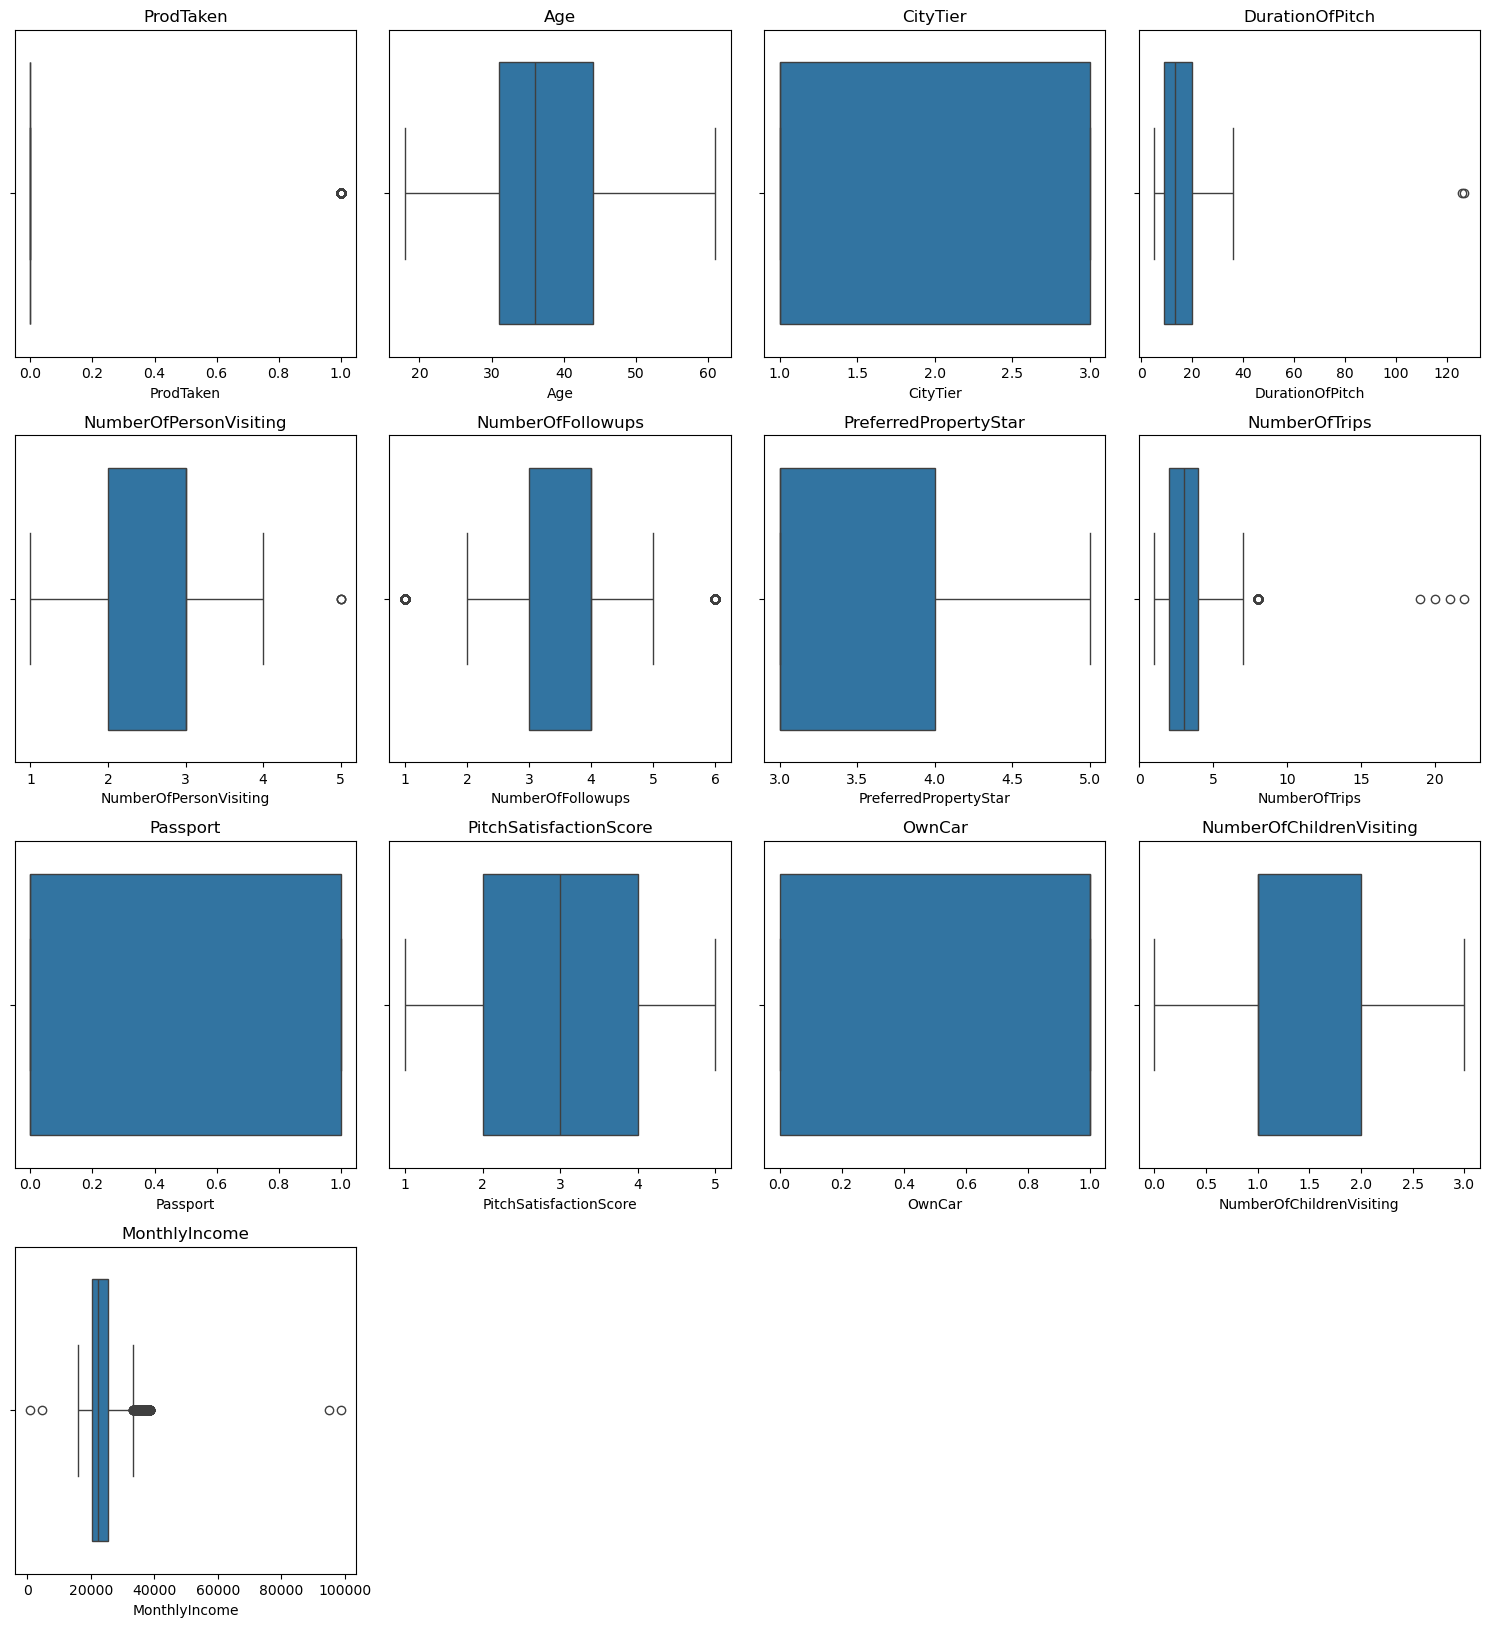

In [9]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [ ]:
# 4.4 Categorical Feature Analysis

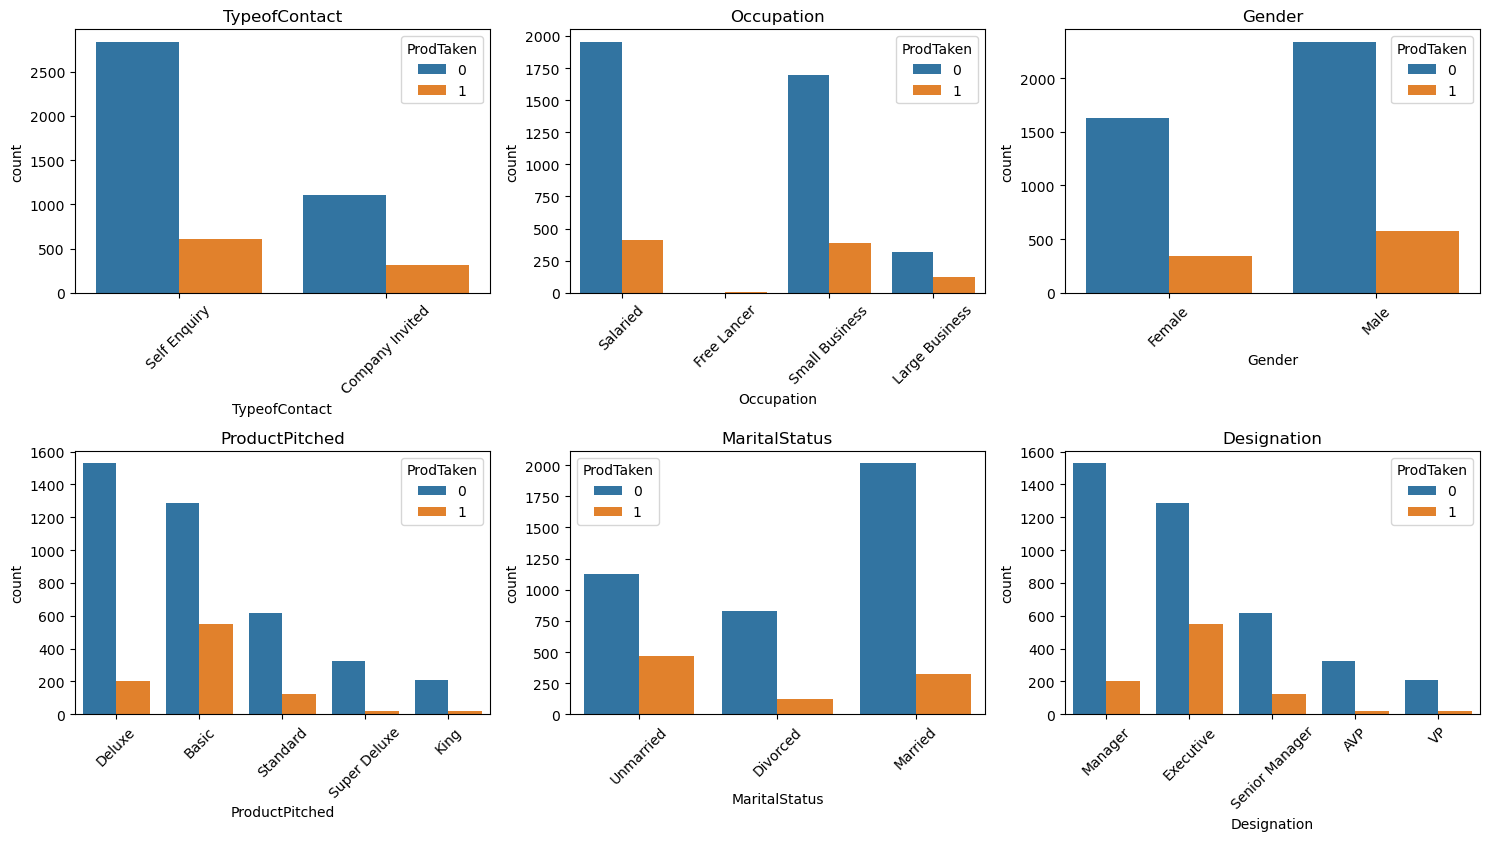

In [10]:
cat_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(5, 3, i)
    sns.countplot(data=df, x=col, hue='ProdTaken')
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# 4.5 Correlation Heatmap

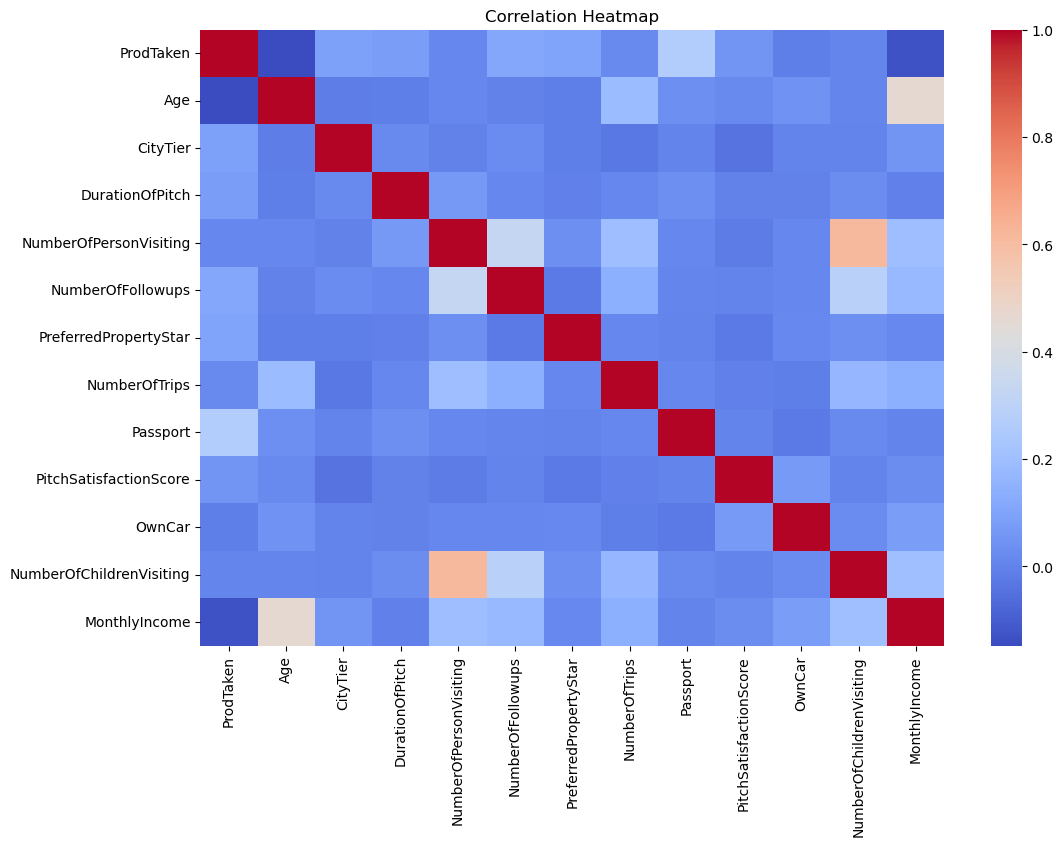

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Missing Value Imputation

In [12]:
df.Age.fillna(df.Age.median(), inplace=True)
df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)
df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace=True)
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace=True)
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace=True)
df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace=True)
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace=True)
df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace=True)

df.isnull().sum()


ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [ ]:
# 6 Feature Engineering

In [13]:
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], inplace=True)


In [ ]:
# 7 Train-Test Split + ColumnTransformer

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer([
    ('oh', oh_transformer, cat_features),
    ('scaler', numeric_transformer, num_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [ ]:
# 8 Train Models (RF, GBM, AdaBoost)

In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Random Forest": RandomForestClassifier(),
    "Gradient Boost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Test Precision': precision_score(y_test, y_test_pred),
        'Test Recall': recall_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred, average='weighted'),
        'Test ROC AUC': roc_auc_score(y_test, y_test_pred)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC
0,Random Forest,0.926380,0.968504,0.643979,0.920410,0.819448
1,Gradient Boost,0.857873,0.776596,0.382199,0.837812,0.677758
2,AdaBoost,0.837423,0.673913,0.324607,0.813797,0.643244


In [ ]:
# 9 Hyperparameter Tuning (RandomizedSearchCV)

In [16]:
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    "n_estimators": [100, 200, 500, 800],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

ada_params = {
    "n_estimators": [50, 80, 100],
    "learning_rate": [0.5, 1.0, 1.5],
    "algorithm": ['SAMME', 'SAMME.R']
}

final_params = {}

for name, model, params in [
    ("Random Forest", RandomForestClassifier(), rf_params),
    ("AdaBoost", AdaBoostClassifier(), ada_params)
]:
    rs = RandomizedSearchCV(model, params, cv=3, n_iter=10, scoring="roc_auc", n_jobs=-1, random_state=42)
    rs.fit(X_train, y_train)
    final_params[name] = rs.best_params_

final_params


{'Random Forest': {'n_estimators': 500,
  'min_samples_split': 2,
  'max_features': 'log2',
  'max_depth': None},
 'AdaBoost': {'n_estimators': 100,
  'learning_rate': 0.5,
  'algorithm': 'SAMME.R'}}

In [ ]:
# 10 Train Final Tuned Models

In [17]:
final_models = {
    "Random Forest": RandomForestClassifier(**final_params["Random Forest"]),
    "AdaBoost": AdaBoostClassifier(**final_params["AdaBoost"])
}

for name, model in final_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    print("ROC AUC:", roc_auc_score(y_test, y_pred))



Random Forest Performance:
Accuracy: 0.9222903885480572
Precision: 0.9752066115702479
Recall: 0.6178010471204188
F1 Score: 0.9152273658901218
ROC AUC: 0.8069945515144661

AdaBoost Performance:
Accuracy: 0.8404907975460123
Precision: 0.7464788732394366
Recall: 0.2774869109947644
F1 Score: 0.8096116491487804
ROC AUC: 0.6273076232229222


In [ ]:
# 11 ROC Curves

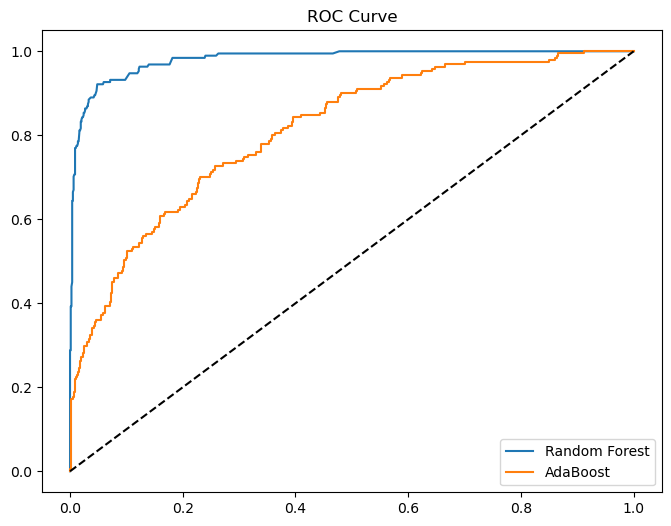

In [18]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))
for name, model in final_models.items():
    y_score = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name}")
plt.plot([0,1], [0,1], 'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()


In [ ]:
# 12 Confusion Matrices

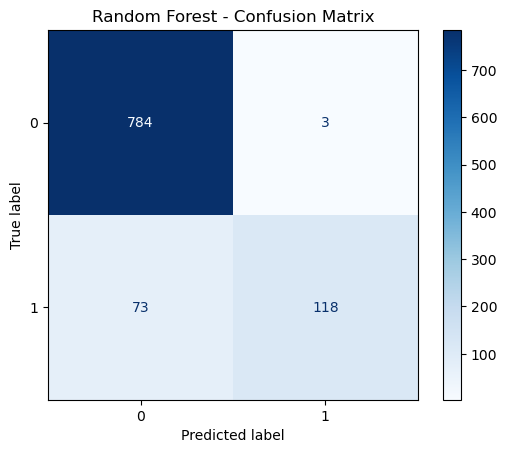

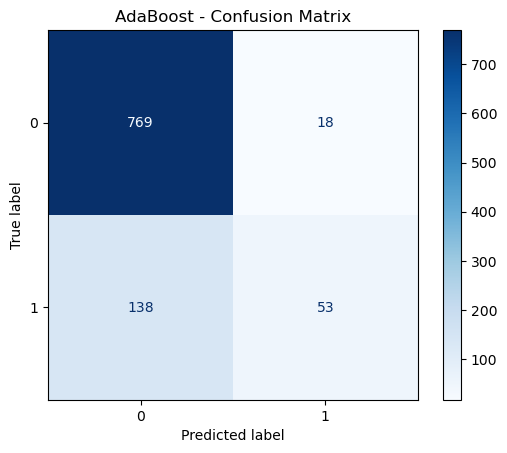

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in final_models.items():
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


In [ ]:
# 13 Final Prediction on New Data

In [20]:
new_data = pd.DataFrame([{
    'Age': 35,
    'TypeofContact': 'Self Enquiry',
    'CityTier': 2,
    'DurationOfPitch': 15,
    'Occupation': 'Salaried',
    'Gender': 'Male',
    'NumberOfFollowups': 3,
    'ProductPitched': 'Deluxe',
    'PreferredPropertyStar': 4,
    'MaritalStatus': 'Married',
    'NumberOfTrips': 2,
    'Passport': 1,
    'PitchSatisfactionScore': 4,
    'OwnCar': 1,
    'NumberOfChildrenVisiting': 1,
    'Designation': 'Executive',
    'MonthlyIncome': 45000,
    'NumberOfPersonVisiting': 2
}])

new_data['TotalVisiting'] = new_data['NumberOfPersonVisiting'] + new_data['NumberOfChildrenVisiting']
new_data.drop(['NumberOfPersonVisiting','NumberOfChildrenVisiting'], axis=1, inplace=True)

new_X = preprocessor.transform(new_data)

for name, model in final_models.items():
    pred = model.predict(new_X)[0]
    prob = model.predict_proba(new_X)[0][1]
    print(f"\n{name} Prediction:")
    print("Will Purchase" if pred==1 else "Will Not Purchase")
    print("Probability:", round(prob, 2))



Random Forest Prediction:
Will Not Purchase
Probability: 0.44

AdaBoost Prediction:
Will Not Purchase
Probability: 0.44
